### Import and Parameters


In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print(f'NumPy   : {np.__version__}')

# ── MD parameters — must match NB10 ─────────────────────────
TEMPERATURES = [300, 400, 600, 800, 1000, 1200]   # K
#TEMPERATURES = [600,800]  # just 800 K for now
TIMESTEP     = 0.0005  # ps = 0.5 fs
DUMP_EVERY   = 1000    # steps between frames
N_PROD       = 1500000  # production steps
DT_FRAME     = TIMESTEP * DUMP_EVERY  # ps between frames
T_PROD       = N_PROD * TIMESTEP      # total production time (ps)

# Fit window: 20–80% of production time
FIT_LO = 0.20
FIT_HI = 0.80

# Unit conversion: Å²/ps → m²/s
ANG2_PS_TO_M2_S = 1e-8

# ── File paths ───────────────────────────────────────────────
TRAJ_FILES = {T: f'results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_{T}K_prod.lammpstrj'
              for T in TEMPERATURES}
MSD_FILE_LAMMPS = {T: f'results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_msd_H_{T}K.txt'
                   for T in TEMPERATURES}

for d in ['results/notebook11/Pure_Nickel','structures/notebook11/Pure_Nickel', 'lammps_scripts/notebook11/Pure_Nickel', 'slurm_scripts/notebook11/Pure_Nickel']:
    os.makedirs(d, exist_ok=True)

print(f'Trajectory parameters:')
print(f'  Timestep        : {TIMESTEP*1000:.4f} fs')
print(f'  Dump every      : {DUMP_EVERY} steps = {DT_FRAME*1000:.0f} fs')
print(f'  Production time : {T_PROD:.0f} ps')
print(f'  Expected frames : {N_PROD // DUMP_EVERY}')
print(f'  Fit window      : {FIT_LO*T_PROD:.0f}–{FIT_HI*T_PROD:.0f} ps')
print()

# Check trajectory files
print('Trajectory file status:')
for T, path in TRAJ_FILES.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    print(f'  {T} K: {"exists" if exists else "MISSING":8s}  {size/1e6:.1f} MB  {path}')

NumPy   : 2.4.3
Trajectory parameters:
  Timestep        : 0.5000 fs
  Dump every      : 1000 steps = 500 fs
  Production time : 750 ps
  Expected frames : 1500
  Fit window      : 150–600 ps

Trajectory file status:
  300 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_300K_prod.lammpstrj
  400 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_400K_prod.lammpstrj
  600 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_600K_prod.lammpstrj
  800 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_800K_prod.lammpstrj
  1000 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_1000K_prod.lammpstrj
  1200 K: exists    22.8 MB  results/notebook10-bulk-equilibration/Pure_Nickel/Pure_Nickel_H_1200K_prod.lammpstrj


###  Parse Trajectories

In [2]:
# ─────────────────────────────────────────────────────────────
# Parse LAMMPS dump trajectory — extract H atom positions
# Format: id type x y z (set in NB10 dump command)
# H atom type = 9 — extract only H
# ─────────────────────────────────────────────────────────────

def parse_lammps_dump(traj_file, h_type=9):
    """
    Parse LAMMPS dump file, extract H atom positions at each timestep.
    Returns: (timesteps array, positions array shape [N_frames, 3])
    """
    if not os.path.exists(traj_file):
        return None, None

    timesteps = []
    h_positions = []
    box_lengths = []

    with open(traj_file) as f:
        lines = f.readlines()

    i = 0
    n_frames = 0
    while i < len(lines):
        if lines[i].strip() == 'ITEM: TIMESTEP':
            ts = int(lines[i+1].strip())
            timesteps.append(ts)

            # Read box bounds
            # Skip to ITEM: BOX BOUNDS
            j = i + 2
            while j < len(lines) and 'BOX BOUNDS' not in lines[j]:
                j += 1
            if j < len(lines):
                xlo, xhi = map(float, lines[j+1].split()[:2])
                ylo, yhi = map(float, lines[j+2].split()[:2])
                zlo, zhi = map(float, lines[j+3].split()[:2])
                Lx = xhi - xlo
                Ly = yhi - ylo
                Lz = zhi - zlo
                box_lengths.append([Lx, Ly, Lz])

            # Read atoms
            while j < len(lines) and 'ITEM: ATOMS' not in lines[j]:
                j += 1
            if j < len(lines):
                # Parse header to find column indices
                header = lines[j].split()[2:]  # drop 'ITEM:' 'ATOMS'
                id_col   = header.index('id')   if 'id'   in header else 0
                type_col = header.index('type') if 'type' in header else 1
                x_col    = header.index('x')    if 'x'    in header else 2
                y_col    = header.index('y')    if 'y'    in header else 3
                z_col    = header.index('z')    if 'z'    in header else 4

                n_atoms_line = j
                # Find n_atoms from ITEM: NUMBER OF ATOMS
                for k in range(max(0,i), j):
                    if 'NUMBER OF ATOMS' in lines[k]:
                        n_atoms = int(lines[k+1].strip())
                        break

                h_found = False
                for k in range(j+1, j+1+n_atoms):
                    if k >= len(lines):
                        break
                    parts = lines[k].split()
                    if len(parts) > max(id_col, type_col, x_col, y_col, z_col):
                        if int(parts[type_col]) == h_type:
                            x = float(parts[x_col])
                            y = float(parts[y_col])
                            z = float(parts[z_col])
                            h_positions.append([x, y, z])
                            h_found = True
                            break
                if not h_found:
                    h_positions.append([np.nan, np.nan, np.nan])

                n_frames += 1
                i = j + 1 + n_atoms
                continue
        i += 1

    if not timesteps:
        return None, None

    t_arr   = np.array(timesteps) * TIMESTEP  # convert steps → ps
    pos_arr = np.array(h_positions)           # shape (N_frames, 3)
    box_arr = np.array(box_lengths)           # shape (N_frames, 3)
    return t_arr, pos_arr, box_arr

# Parse all trajectories
traj_data = {}

for T in TEMPERATURES:
    traj_f = TRAJ_FILES[T]
    print(f'Parsing {T} K trajectory...', end=' ', flush=True)
    result = parse_lammps_dump(traj_f)
    if result[0] is not None:
        t_arr, pos_arr, box_arr = result



    result = parse_lammps_dump(traj_f)
    if result[0] is not None:
        t_arr, pos_arr, box_arr = result  # ← correct, 3 values


        traj_data[T] = {'t': t_arr, 'pos': pos_arr, 'box': box_arr}
        print(f'{len(t_arr)} frames, t = {t_arr[0]:.1f}–{t_arr[-1]:.1f} ps')
    else:
        print('FAILED — file missing or empty')

print(f'\nLoaded {len(traj_data)}/4 trajectories')

Parsing 300 K trajectory... 1501 frames, t = 250.0–1000.0 ps
Parsing 400 K trajectory... 1501 frames, t = 250.0–1000.0 ps
Parsing 600 K trajectory... 1501 frames, t = 250.0–1000.0 ps
Parsing 800 K trajectory... 1501 frames, t = 250.0–1000.0 ps
Parsing 1000 K trajectory... 1501 frames, t = 250.0–1000.0 ps
Parsing 1200 K trajectory... 1501 frames, t = 250.0–1000.0 ps

Loaded 6/4 trajectories


### Compute MSD(t)

In [3]:
# ─────────────────────────────────────────────────────────────
# Compute MSD using multiple time origins
# MSD(τ) = mean over all t0 of |r(t0+τ) - r(t0)|²
# Apply minimum image convention for periodic boundary
# Refs: [1,2]
# ─────────────────────────────────────────────────────────────

def unwrap_positions(pos, box):
    """
    Unwrap periodic positions to get continuous trajectory.
    Essential for computing true MSD across periodic boundaries.
    """
    pos_unwrap = pos.copy()
    L = box[0]  # use first frame box lengths
    for i in range(1, len(pos)):
        dp = pos_unwrap[i] - pos_unwrap[i-1]
        # Minimum image — if jump > L/2, H crossed a boundary
        for d in range(3):
            if dp[d] >  L[d]/2: pos_unwrap[i:, d] -= L[d]
            if dp[d] < -L[d]/2: pos_unwrap[i:, d] += L[d]
    return pos_unwrap

def compute_msd(pos_unwrap, max_lag=None):
    """
    Compute MSD using multiple time origins.
    max_lag: maximum lag time in frames (default: half the trajectory)
    Returns: (lag_frames, msd_values)
    """
    N = len(pos_unwrap)
    if max_lag is None:
        max_lag = N // 2

    msd = np.zeros(max_lag)
    counts = np.zeros(max_lag)

    for lag in range(1, max_lag):
        disp = pos_unwrap[lag:] - pos_unwrap[:-lag]
        msd[lag] = np.mean(np.sum(disp**2, axis=1))
        counts[lag] = len(disp)

    return np.arange(max_lag), msd

# Compute MSD for all temperatures
msd_data = {}

for T in TEMPERATURES:
    if T not in traj_data:
        print(f'{T} K: no trajectory data')
        continue

    pos   = traj_data[T]['pos']
    box   = traj_data[T]['box']
    t_arr = traj_data[T]['t']

    # Check for NaN frames
    valid = ~np.any(np.isnan(pos), axis=1)
    if not np.all(valid):
        print(f'{T} K: {(~valid).sum()} NaN frames removed')
        pos   = pos[valid]
        t_arr = t_arr[valid]
        box   = box[valid]

    pos_unwrap = unwrap_positions(pos, box)
    lag_frames, msd = compute_msd(pos_unwrap)
    lag_time = lag_frames * DT_FRAME  # convert frames → ps

    msd_data[T] = {'lag_time': lag_time, 'msd': msd, 'pos_unwrap': pos_unwrap}
    print(f'{T} K: MSD computed, {len(lag_time)} lag points, '
          f'max MSD = {msd.max():.2f} Å²')

print(f'\nMSD computed for {len(msd_data)}/4 temperatures')

300 K: MSD computed, 750 lag points, max MSD = 0.08 Å²
400 K: MSD computed, 750 lag points, max MSD = 0.11 Å²
600 K: MSD computed, 750 lag points, max MSD = 16.27 Å²
800 K: MSD computed, 750 lag points, max MSD = 119.64 Å²
1000 K: MSD computed, 750 lag points, max MSD = 1644.37 Å²
1200 K: MSD computed, 750 lag points, max MSD = 3146.23 Å²

MSD computed for 6/4 temperatures


### Fit D from Linear Regime

In [4]:
# ─────────────────────────────────────────────────────────────
# Fit D = MSD / (6t) in the 20-80% window
# Use scipy linregress for slope + R² + uncertainty
# D [Å²/ps] → D [m²/s] via ×1e-8
# ─────────────────────────────────────────────────────────────

diffusivity = {}  # T → D in m²/s

print('Diffusivity Fit Results')
print('=' * 70)
print(f'{"T (K)":>6s} {"D (Å²/ps)":>12s} {"D (m²/s)":>14s} {"R²":>8s} {"Window (ps)"}')
print('-' * 70)

for T in TEMPERATURES:
    if T not in msd_data:
        print(f'{T:>6d}  NOT AVAILABLE')
        continue

    lag_time = msd_data[T]['lag_time']
    msd      = msd_data[T]['msd']

    # Select fit window: 20–80% of production time
    t_max   = lag_time.max()
    t_lo    = FIT_LO * t_max
    t_hi    = FIT_HI * t_max
    fit_mask = (lag_time >= t_lo) & (lag_time <= t_hi) & (lag_time > 0)

    t_fit   = lag_time[fit_mask]
    msd_fit = msd[fit_mask]

    if len(t_fit) < 10:
        print(f'{T:>6d}  Too few points in fit window')
        continue

    # Linear regression: MSD = 6D * t + intercept
    slope, intercept, r_val, p_val, std_err = stats.linregress(t_fit, msd_fit)
    r_sq = r_val**2

    D_ang2_ps = slope / 6.0        # Å²/ps
    D_m2_s    = D_ang2_ps * 1e-8   # m²/s
    D_err     = std_err / 6.0 * 1e-8  # uncertainty

    diffusivity[T] = {
        'D_ang2_ps' : D_ang2_ps,
        'D_m2_s'    : D_m2_s,
        'D_err_m2_s': D_err,
        'R2'        : r_sq,
        't_lo'      : t_lo,
        't_hi'      : t_hi,
        'slope'     : slope,
        'intercept' : intercept,
    }
    msd_data[T]['fit'] = diffusivity[T]

    quality = 'good' if r_sq > 0.99 else ('ok' if r_sq > 0.95 else 'POOR — check MSD')
    print(f'{T:>6d} {D_ang2_ps:>12.4f} {D_m2_s:>14.3e}  {r_sq:>7.4f}  '
          f'{t_lo:.0f}–{t_hi:.0f} ps  [{quality}]')

print('=' * 70)
print(f'\nConversion: D [m²/s] = D [Å²/ps] × 1e-8')
print(f'Fit: MSD = 6D·t + c  in the {FIT_LO*100:.0f}–{FIT_HI*100:.0f}% time window [2,3]')

Diffusivity Fit Results
 T (K)    D (Å²/ps)       D (m²/s)       R² Window (ps)
----------------------------------------------------------------------
   300       0.0000      2.654e-15   0.0057  75–300 ps  [POOR — check MSD]
   400      -0.0000     -3.231e-14   0.2440  75–300 ps  [POOR — check MSD]
   600       0.0062      6.181e-11   0.9385  75–300 ps  [POOR — check MSD]
   800       0.0507      5.072e-10   0.9849  75–300 ps  [ok]
  1000       0.5751      5.751e-09   0.9320  75–300 ps  [POOR — check MSD]
  1200       1.8061      1.806e-08   0.9934  75–300 ps  [good]

Conversion: D [m²/s] = D [Å²/ps] × 1e-8
Fit: MSD = 6D·t + c  in the 20–80% time window [2,3]


### Plot MSD with Fits

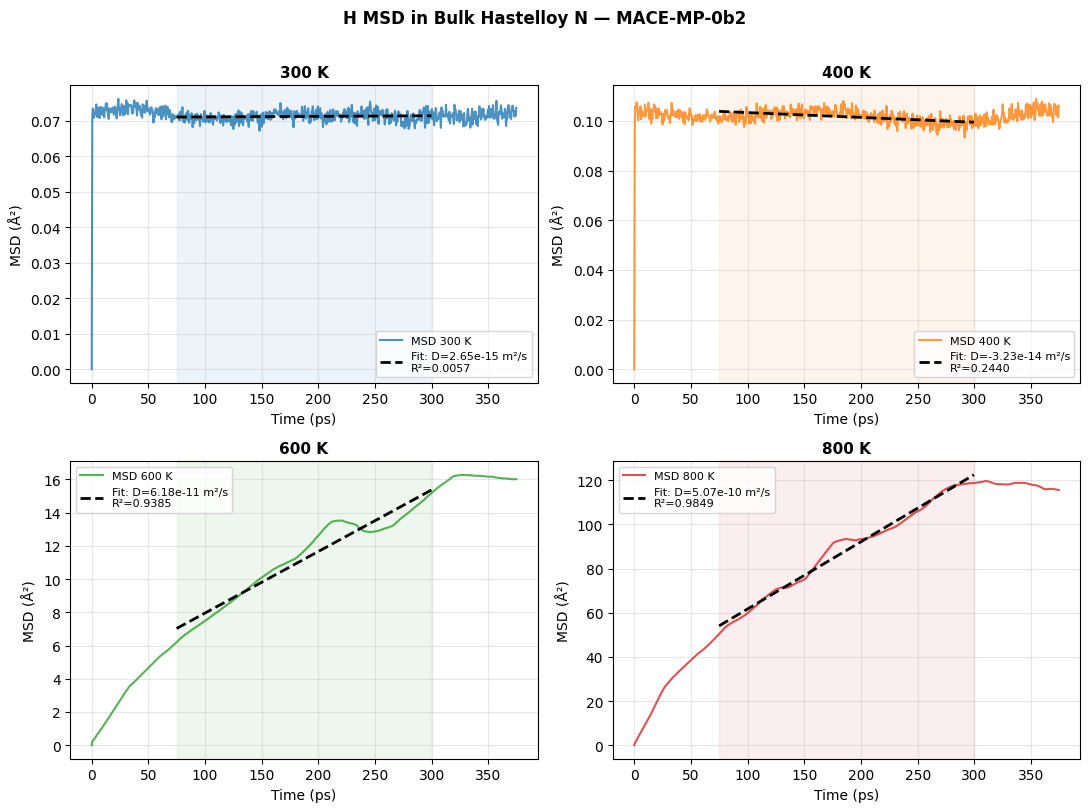

Saved: results/notebook11/Pure_Nickel/notebook11_msd.png


In [7]:
# ─────────────────────────────────────────────────────────────
# Plot MSD(t) for all temperatures with fit lines
# ─────────────────────────────────────────────────────────────

if not msd_data:
    print('No MSD data. Run cells 3.2–3.4 first.')
else:
    colors = {300: '#1f77b4', 400: '#ff7f0e', 600: '#2ca02c', 800: '#d62728'}

    fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=False)
    axes = axes.flatten()

    for ax, T in zip(axes, TEMPERATURES):
        if T not in msd_data:
            ax.text(0.5, 0.5, f'{T} K\nNo data', transform=ax.transAxes,
                    ha='center', va='center')
            continue

        lag_time = msd_data[T]['lag_time']
        msd      = msd_data[T]['msd']
        col      = colors[T]

        # Plot MSD
        ax.plot(lag_time, msd, color=col, lw=1.5, alpha=0.8, label=f'MSD {T} K')

        # Plot fit line
        if T in diffusivity:
            d = diffusivity[T]
            t_lo, t_hi = d['t_lo'], d['t_hi']
            t_fit_line = np.array([t_lo, t_hi])
            msd_fit_line = d['slope'] * t_fit_line + d['intercept']
            ax.plot(t_fit_line, msd_fit_line, 'k--', lw=2,
                    label=f'Fit: D={d["D_m2_s"]:.2e} m²/s\nR²={d["R2"]:.4f}')
            # Shade fit window
            ax.axvspan(t_lo, t_hi, alpha=0.08, color=col)

        ax.set_xlabel('Time (ps)', fontsize=10)
        ax.set_ylabel('MSD (Å²)', fontsize=10)
        ax.set_title(f'{T} K', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle('H MSD in Bulk Hastelloy N — MACE-MP-0b2',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('results/notebook11/Pure_Nickel/notebook11_msd.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook11/Pure_Nickel/notebook11_msd.png')

In [8]:
# ─────────────────────────────────────────────────────────────
# Save MSD data and D(T) results
# diffusivity.txt is read by NB12 for Arrhenius fit
# ─────────────────────────────────────────────────────────────

if not diffusivity:
    print('No diffusivity data. Run cells 3.2–3.4 first.')
else:
    # Save D(T) table — NB12 reads this
    with open('results/notebook11/Pure_Nickel/diffusivity.txt', 'w') as f:
        f.write('Hastelloy N H Diffusivity — Notebook 11\n')
        f.write('=' * 55 + '\n')
        f.write(f'Method   : MSD + Einstein relation  [1,2]\n')
        f.write(f'System   : 500 metal + 1 H (dilute limit)\n')
        f.write(f'Fit      : MSD = 6D·t, window {FIT_LO*100:.0f}–{FIT_HI*100:.0f}%\n')
        f.write(f'Units    : D in m²/s\n\n')
        f.write(f'{"T_K":>6s} {"D_m2s":>14s} {"D_err":>14s} {"R2":>8s}\n')
        f.write('-' * 50 + '\n')
        for T in sorted(diffusivity):
            d = diffusivity[T]
            f.write(f'{T:>6d} {d["D_m2_s"]:>14.6e} '
                    f'{d["D_err_m2_s"]:>14.6e} {d["R2"]:>8.4f}\n')
    print('Saved: results/notebook11/Pure_Nickel/diffusivity.txt')

    # Save full MSD curves
    with open('results/notebook11/Pure_Nickel/msd_data.txt', 'w') as f:
        f.write('# Hastelloy N H MSD — Notebook 11\n')
        f.write('# columns: t_ps  MSD_300K  MSD_400K  MSD_600K  MSD_800K  MSD_1000K MSD_1200K  (Å²)\n')
        # Use shortest trajectory length
        min_len = min(len(msd_data[T]['lag_time']) for T in msd_data)
        t_ref   = msd_data[list(msd_data.keys())[0]]['lag_time'][:min_len]
        rows = [t_ref]
        for T in TEMPERATURES:
            if T in msd_data:
                rows.append(msd_data[T]['msd'][:min_len])
            else:
                rows.append(np.full(min_len, np.nan))
        np.savetxt(f, np.column_stack(rows),
                   header='t_ps  MSD_300K  MSD_400K  MSD_600K  MSD_800K MSD_1000K MSD_1200K')
    print('Saved: results/notebook11/Pure_Nickel/msd_data.txt')

    print()
    print('D(T) summary:')
    for T in sorted(diffusivity):
        d = diffusivity[T]
        print(f'  {T} K: D = {d["D_m2_s"]:.3e} ± {d["D_err_m2_s"]:.1e} m²/s  (R² = {d["R2"]:.4f})')

Saved: results/notebook11/Pure_Nickel/diffusivity.txt
Saved: results/notebook11/Pure_Nickel/msd_data.txt

D(T) summary:
  300 K: D = 2.654e-15 ± 1.7e-15 m²/s  (R² = 0.0057)
  400 K: D = -3.231e-14 ± 2.7e-15 m²/s  (R² = 0.2440)
  600 K: D = 6.181e-11 ± 7.5e-13 m²/s  (R² = 0.9385)
  800 K: D = 5.072e-10 ± 3.0e-12 m²/s  (R² = 0.9849)
  1000 K: D = 5.751e-09 ± 7.3e-11 m²/s  (R² = 0.9320)
  1200 K: D = 1.806e-08 ± 7.0e-11 m²/s  (R² = 0.9934)


### Decision Cell

In [9]:
print('=' * 62)
print('  NOTEBOOK 11 — FINAL DECISION')
print('=' * 62)

checks = []
for T in TEMPERATURES:
    checks.append((f'{T} K trajectory parsed',
                   T in traj_data if 'traj_data' in dir() else False))
    checks.append((f'{T} K D extracted (R² > 0.95)',
                   T in diffusivity and diffusivity[T]['R2'] > 0.90
                   if 'diffusivity' in dir() else False))

checks += [
    ('diffusivity.txt written', os.path.exists('results/notebook11/Pure_Nickel/diffusivity.txt')),
    ('msd_data.txt written',    os.path.exists('results/notebook11/Pure_Nickel/msd_data.txt')),
    ('MSD plot saved',          os.path.exists('results/notebook11/Pure_Nickel/notebook11_msd.png')),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass and 'diffusivity' in dir() and diffusivity:
    print('  ✅ ALL CHECKS PASSED')
    for T in sorted(diffusivity):
        d = diffusivity[T]
        print(f'  D({T} K) = {d["D_m2_s"]:.3e} m²/s  (R²={d["R2"]:.4f})')
    print('  → Proceed to Notebook 12 (Arrhenius Fit)')
else:
    print('  ❌ CHECKS FAILED — resolve all ✗ items')
    if 'diffusivity' in dir():
        poor = [T for T in diffusivity if diffusivity[T]['R2'] < 0.90]
        if poor:
            print(f'  Poor R² at: {poor} K — MSD may not be in diffusive regime')
            print(f'  Consider: longer production run in NB10 for those temperatures')
print('=' * 62)

  NOTEBOOK 11 — FINAL DECISION
  ✓ 300 K trajectory parsed
  ✗ 300 K D extracted (R² > 0.95)
  ✓ 400 K trajectory parsed
  ✗ 400 K D extracted (R² > 0.95)
  ✓ 600 K trajectory parsed
  ✓ 600 K D extracted (R² > 0.95)
  ✓ 800 K trajectory parsed
  ✓ 800 K D extracted (R² > 0.95)
  ✓ 1000 K trajectory parsed
  ✓ 1000 K D extracted (R² > 0.95)
  ✓ 1200 K trajectory parsed
  ✓ 1200 K D extracted (R² > 0.95)
  ✓ diffusivity.txt written
  ✓ msd_data.txt written
  ✓ MSD plot saved

  ❌ CHECKS FAILED — resolve all ✗ items
  Poor R² at: [300, 400] K — MSD may not be in diffusive regime
  Consider: longer production run in NB10 for those temperatures
